In [3]:
%pip install pyathena

Note: you may need to restart the kernel to use updated packages.


<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9340/1241097734.py:19: SyntaxWarning: invalid escape sequence '\d'
  filtered_df['id'] = filtered_df['vehicle_id'].str.extract('(\d+)').astype(int)
/tmp/ipykernel_9340/1241097734.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Column names in Data Frame: Index(['vehicle_id', 'max_co2'], dtype='object')


/tmp/ipykernel_9340/1241097734.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = filtered_df[df['vehicle_id'].str.contains(r'Vehicle_\d+', na = False)]


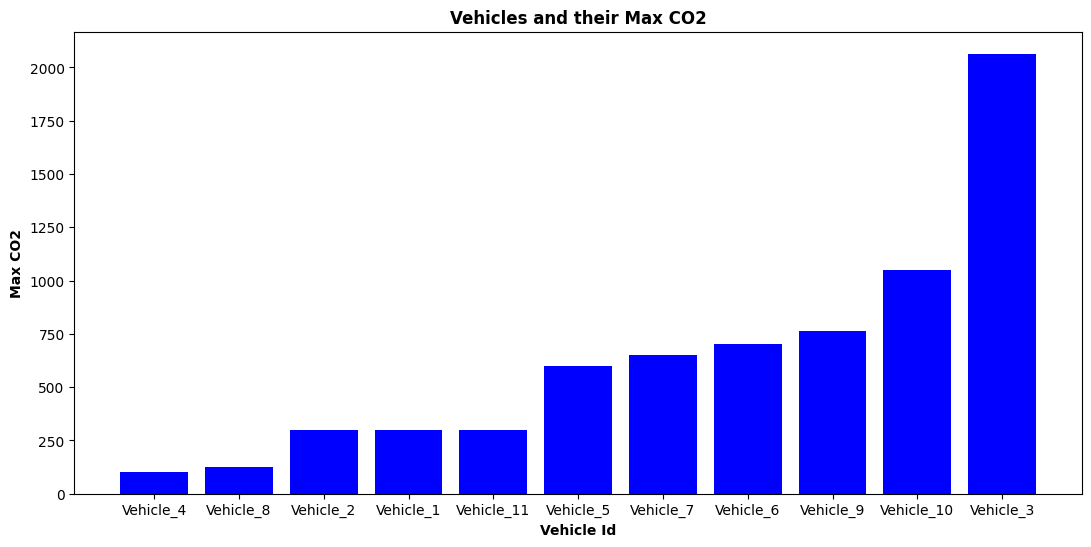

['100.0' '123.0' '300.0' '600.0' '650.0' '700.0' '762.0' '1050.0' '2065.0']
[1 1 3 1 1 1 1 1 1]


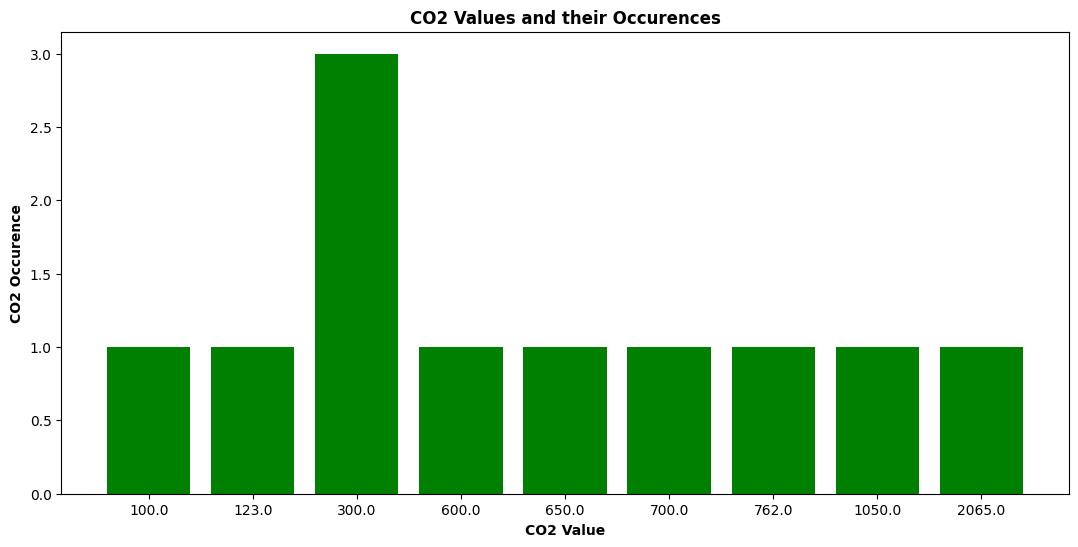

,vehicle_id,max_co2,id
0,Vehicle_1,300.0,1
2,Vehicle_2,300.0,2
165,Vehicle_3,2065.0,3
209,Vehicle_4,100.0,4
275,Vehicle_5,600.0,5
18,Vehicle_6,700.0,6
339,Vehicle_7,650.0,7
407,Vehicle_8,123.0,8
466,Vehicle_9,762.0,9
528,Vehicle_10,1050.0,10


In [60]:
from pyathena import connect
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#Connect to lab4 S3 Container
conn = connect(s3_staging_dir='s3://lab4-finaldata/', region_name='us-east-1')

#Connect to Lab4 data base
query = 'SELECT vehicle_id, max_co2 FROM "lab4-gluedatabase"."lab4_firehose_destination"'
df = pd.read_sql(query, conn)
print("Column names in Data Frame:", df.columns)

#Get only the most recent data points
filtered_df = df.drop_duplicates(subset=['vehicle_id'], keep='first')

#Remove unused data points
filtered_df = filtered_df[df['vehicle_id'].str.contains(r'Vehicle_\d+', na = False)]

#Filter data points by number
filtered_df['id'] = filtered_df['vehicle_id'].str.extract('(\d+)').astype(int)
filtered_df = filtered_df.sort_values(by='id', ascending=True)

#Sort Data by CO2 usage
df_co_usage = filtered_df.sort_values(by='max_co2', ascending=True)

#Graph
plt.figure(figsize=(13,6))
plt.bar(df_co_usage['vehicle_id'], df_co_usage['max_co2'], color='Blue')

plt.title("Vehicles and their Max CO2", fontweight='bold')
plt.xlabel("Vehicle Id", fontweight='bold')
plt.ylabel("Max CO2", fontweight='bold')

plt.show()

#Sort Data by C02 value occurence
co2_occurence_combined = filtered_df['max_co2'].value_counts().sort_index()
co2_vals = co2_occurence_combined.index.to_numpy().astype(str)
co2_occurence = co2_occurence_combined.to_numpy()
#co2_occurence.head(11)

print(co2_vals)
print(co2_occurence)

#Graph
plt.figure(figsize=(13,6))
plt.bar(co2_vals, co2_occurence, color='Green')

plt.title("CO2 Values and their Occurences", fontweight='bold')
plt.xlabel("CO2 Value", fontweight='bold')
plt.ylabel("CO2 Occurence", fontweight='bold')

plt.show()

#Display Data
filtered_df.head(11)